# 第9回 Python セミナー：QM9 バンドギャップ予測コンペ解法

配布データの `smiles` から特徴量を生成し，`gap_eV`（HOMO-LUMO ギャップ，単位 eV）を予測する回帰モデルを構築する．評価指標は MAE（平均絶対誤差）である．

## 方針（計算コストより性能を重視）

1. RDKit で 3 種類の特徴量を生成する（2D 記述子 217 個，Morgan カウントフィンガープリント 2048 次元，MACCS keys 167 次元）．
2. 勾配ブースティング 3 モデル（LightGBM，XGBoost，CatBoost）を学習する．LightGBM と XGBoost は Optuna でハイパーパラメータを最適化する．
3. 5-fold クロスバリデーションの Out-of-Fold（OOF）予測で各モデルを評価し，OOF 上で最適化した重み付き平均（ブレンド）を本命の提出値とする．

## レギュレーションへの対応

| 規則 | 対応 |
| --- | --- |
| データの追加禁止 | 配布 CSV のみ使用．特徴量はすべて `smiles` から生成 |
| モデルは 0 から学習 | 事前学習済みモデルを使わず，本ノートブック内で学習 |
| LLM・NNP の禁止 | 勾配ブースティング決定木のみ使用 |
| 提出モデル最大 3 個 | LightGBM，XGBoost，CatBoost の 3 モデル．予測値の組み合わせは規則 5.2 で許可 |
| 乱数シード | 推奨値 8 に固定 |
| 提出 CSV | `smiles,gap_eV` の列順で 4,000 行 |

**主催者への確認事項（規則 8 章に対応）**：ブレンド（複数予測値の組み合わせ）を何モデルと数えるかは未確定のため，基礎モデルを 3 個以内に抑えた上で，単体モデルの提出物も用意した．

## 実行時間の目安

フル設定の実測は 152.8 分であった（Apple Silicon，CPU のみ．Optuna の探索には時間上限を設定しているが，1 trial が長いため多少超過する）．環境変数 `QM9_QUICK=1` を設定して実行すると，データを間引いた動作確認モード（10 分弱）になる．

## 用語解説（規則 3.3 対応）

- **QM9**：炭素・水素・酸素・窒素・フッ素からなる重原子 9 個以下の有機低分子約 13.4 万件について，DFT 計算（B3LYP/6-31G(2df,p)）で得た構造と物性（HOMO-LUMO ギャップ，双極子モーメントなど）を収録した量子化学データセット．本コンペの `gap_eV` は HOMO-LUMO ギャップに対応する．
- **RDKit**：オープンソースのケモインフォマティクスライブラリ．SMILES の解析，分子記述子の計算，フィンガープリントの生成などに使う．
- **SMILES**：分子構造を 1 行の文字列で表す記法（例：`c1ccccc1` はベンゼン）．
- **分子記述子**：分子全体から計算される数値特徴量（分子量，LogP，トポロジカル極性表面積 TPSA，環の数など）．
- **フィンガープリント**：分子中の部分構造の有無や出現回数を固定長ベクトルに符号化した表現．Morgan フィンガープリント（ECFP 相当）は各原子から半径 r 以内の部分構造をハッシュ化する．本ノートブックではビットの有無ではなく出現回数（カウント）を使う．

## 1. セットアップ

乱数シードは推奨値 8 に固定する．図中の文字は英語で統一する（文書作成ルールに合わせる）．

In [1]:
%matplotlib inline
import os
import time
import warnings

# ipywidgets 未導入環境での tqdm の表示警告を抑制する（optuna の import より前に設定）
warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", category=UserWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import lightgbm as lgb
import optuna
import xgboost as xgb
from catboost import CatBoostRegressor
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import Descriptors, MACCSkeys, rdFingerprintGenerator
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold

SEED = 8
QUICK = os.environ.get("QM9_QUICK", "0") == "1"

N_SPLITS = 3 if QUICK else 5          # OOF 評価の fold 数
SEARCH_SPLITS = 2 if QUICK else 3     # Optuna 探索時の fold 数
LGB_TRIALS = 4 if QUICK else 60
XGB_TRIALS = 3 if QUICK else 40
LGB_TIMEOUT = 120 if QUICK else 1800  # 探索の時間上限（秒）
XGB_TIMEOUT = 90 if QUICK else 1200
N_EST_SEARCH = 800 if QUICK else 3500
ES_SEARCH = 50 if QUICK else 100      # 探索時の early stopping
ES_OOF = 50 if QUICK else 150         # OOF 評価時の early stopping
CAT_ITERS = 800 if QUICK else 6000
TRAIN_SUBSAMPLE = 2500 if QUICK else None

np.random.seed(SEED)
RDLogger.DisableLog("rdApp.*")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 図の配色（コントラスト・色覚多様性を検証済みのパレット）
C_BLUE = "#2a78d6"
C_INK = "#0b0b0b"
C_SEC = "#52514e"
C_MUTED = "#898781"
C_GRID = "#e1e0d9"
C_BASE = "#c3c2b7"
C_SURF = "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": C_SURF, "axes.facecolor": C_SURF, "savefig.facecolor": C_SURF,
    "axes.edgecolor": C_BASE, "axes.labelcolor": C_SEC, "text.color": C_INK,
    "xtick.color": C_MUTED, "ytick.color": C_MUTED,
    "axes.grid": True, "grid.color": C_GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "axes.axisbelow": True,
    "font.size": 11, "figure.dpi": 110,
})

T_START = time.time()
if QUICK:
    print("*** QUICK モード（動作確認用）：データを間引き，探索回数を減らして実行する ***")
import catboost
import rdkit
import sklearn
for name, mod in [("numpy", np), ("pandas", pd), ("scikit-learn", sklearn),
                  ("lightgbm", lgb), ("xgboost", xgb), ("catboost", catboost),
                  ("optuna", optuna), ("rdkit", rdkit)]:
    print(f"{name}: {mod.__version__}")
print(f"SEED = {SEED}, QUICK = {QUICK}")

numpy: 2.4.6
pandas: 3.0.3
scikit-learn: 1.9.0
lightgbm: 4.6.0
xgboost: 3.2.0
catboost: 1.2.10
optuna: 4.9.0
rdkit: 2026.03.4
SEED = 8, QUICK = False


## 2. データ読み込みと確認

学習データ 15,000 行と，正解のないテストデータ 4,000 行を読み込み，行数・欠損・重複を確認する．

In [2]:
train_df = pd.read_csv("qm9_bandgap_train.csv")
test_df = pd.read_csv("qm9_bandgap_test_without_answer.csv")

print(f"train: {train_df.shape}, test: {test_df.shape}")
assert list(train_df.columns) == ["smiles", "gap_eV"]
assert list(test_df.columns) == ["smiles"]
assert train_df["gap_eV"].notna().all(), "gap_eV に欠損がある"

print(f"train 内の smiles 重複: {train_df['smiles'].duplicated().sum()} 件")
print(f"test 内の smiles 重複: {test_df['smiles'].duplicated().sum()} 件")
print(f"train と test で共通の smiles: {len(set(train_df['smiles']) & set(test_df['smiles']))} 件")

if TRAIN_SUBSAMPLE is not None:
    train_df = train_df.sample(TRAIN_SUBSAMPLE, random_state=SEED).reset_index(drop=True)
    print(f"QUICK モード：学習データを {len(train_df)} 行に間引いた")

train_df["gap_eV"].describe()

train: (15000, 2), test: (4000, 1)
train 内の smiles 重複: 2 件
test 内の smiles 重複: 0 件
train と test で共通の smiles: 0 件


count    15000.000000
mean         6.823883
std          1.288640
min          1.774183
25%          5.885826
50%          6.781081
75%          7.834162
max         10.718570
Name: gap_eV, dtype: float64

## 3. 目的変数の分布

`gap_eV` の分布を確認する．極端な外れ値や多峰性があれば前処理・モデル選択の参考にする．

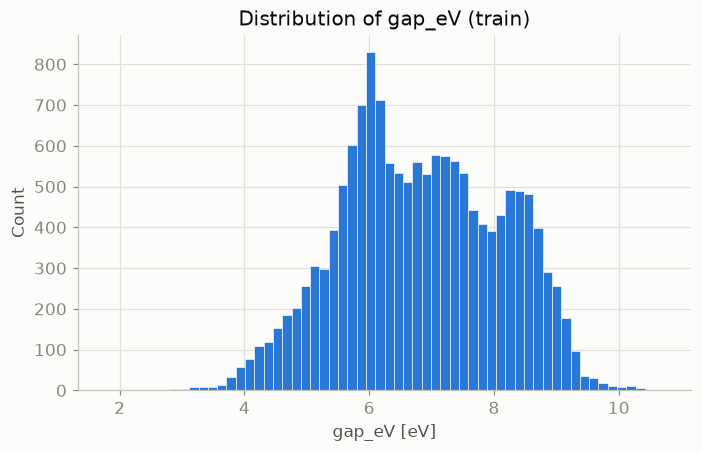

min = 1.774, max = 10.719, mean = 6.824, std = 1.289 eV


In [3]:
gap = train_df["gap_eV"].to_numpy()
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.hist(gap, bins=60, color=C_BLUE, edgecolor="white", linewidth=0.4)
ax.set_title("Distribution of gap_eV (train)")
ax.set_xlabel("gap_eV [eV]")
ax.set_ylabel("Count")
plt.show()
print(f"min = {gap.min():.3f}, max = {gap.max():.3f}, "
      f"mean = {gap.mean():.3f}, std = {gap.std():.3f} eV")

## 4. SMILES からの特徴量生成

規則 5.1 のとおり，特徴量はすべて配布された `smiles` から生成する．

| 特徴量 | 次元 | 内容 |
| --- | ---: | --- |
| RDKit 2D 記述子 | 217 | 分子量，LogP，TPSA，環数などの物理化学的記述子 |
| Morgan カウント FP | 2048 | 半径 2 の部分構造の出現回数（ECFP4 相当のカウント版） |
| MACCS keys | 167 | 定義済み部分構造の有無 |

前処理はリーク防止のため学習データの統計量だけで行う（中央値補完，定数列の除去）．SMILES の解析に失敗した行は，学習データでは除外し，テストデータでは中央値ベクトルで補完して 4,000 行を厳守する．

In [4]:
MORGAN_GEN = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)


def featurize(smiles_list, label):
    # SMILES の列から（記述子 DataFrame, Morgan カウント FP, MACCS, 解析成功フラグ）を作る
    desc_rows, fp_rows, maccs_rows, ok = [], [], [], []
    for i, smi in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            ok.append(False)
            desc_rows.append({})
            fp_rows.append(np.zeros(2048, dtype=np.float32))
            maccs_rows.append(np.zeros(167, dtype=np.float32))
        else:
            ok.append(True)
            desc_rows.append(Descriptors.CalcMolDescriptors(mol, missingVal=np.nan, silent=True))
            fp_rows.append(MORGAN_GEN.GetCountFingerprintAsNumPy(mol).astype(np.float32))
            arr = np.zeros((167,), dtype=np.float32)
            DataStructs.ConvertToNumpyArray(MACCSkeys.GenMACCSKeys(mol), arr)
            maccs_rows.append(arr)
        if (i + 1) % 5000 == 0:
            print(f"  {label}: {i + 1}/{len(smiles_list)} 分子を処理")
    desc_df = pd.DataFrame(desc_rows).astype(np.float32)
    return desc_df, np.vstack(fp_rows), np.vstack(maccs_rows), np.array(ok, dtype=bool)

In [5]:
t0 = time.time()
train_desc, train_fp, train_maccs, train_ok = featurize(train_df["smiles"], "train")
test_desc, test_fp, test_maccs, test_ok = featurize(test_df["smiles"], "test")
print(f"特徴量生成: {time.time() - t0:.0f} 秒")
print(f"SMILES 解析失敗: train {int((~train_ok).sum())} 件, test {int((~test_ok).sum())} 件")

# 記述子の列順を train に合わせる
test_desc = test_desc.reindex(columns=train_desc.columns)

feat_names = (
    list(train_desc.columns)
    + [f"mfp_{i}" for i in range(train_fp.shape[1])]
    + [f"maccs_{i}" for i in range(train_maccs.shape[1])]
)
X_train_raw = np.hstack([train_desc.to_numpy(np.float32), train_fp, train_maccs])
X_test_raw = np.hstack([test_desc.to_numpy(np.float32), test_fp, test_maccs])

# 解析に失敗した学習行を除外
X_train_raw = X_train_raw[train_ok]
y = train_df.loc[train_ok, "gap_eV"].to_numpy(np.float64)
print(f"学習に使う行数: {len(y)}")

# クリーニング（統計量は train のみから計算し，リークを防ぐ）
X_train_raw[~np.isfinite(X_train_raw)] = np.nan
X_test_raw[~np.isfinite(X_test_raw)] = np.nan
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    med = np.nanmedian(X_train_raw, axis=0)
med = np.nan_to_num(med, nan=0.0).astype(np.float32)
X_train_raw = np.where(np.isnan(X_train_raw), med, X_train_raw)
X_test_raw = np.where(np.isnan(X_test_raw), med, X_test_raw)

keep = X_train_raw.std(axis=0) > 0
X_train = np.ascontiguousarray(X_train_raw[:, keep], dtype=np.float32)
X_test = np.ascontiguousarray(X_test_raw[:, keep], dtype=np.float32)
feat_names = [n for n, k in zip(feat_names, keep) if k]
print(f"特徴量次元: {len(keep)} -> {X_train.shape[1]}（定数列を除去）")
assert np.isfinite(X_train).all() and np.isfinite(X_test).all()

  train: 5000/15000 分子を処理
  train: 10000/15000 分子を処理
  train: 15000/15000 分子を処理
特徴量生成: 173 秒
SMILES 解析失敗: train 0 件, test 0 件
学習に使う行数: 15000
特徴量次元: 2432 -> 2357（定数列を除去）


## 5. 検証設計とベースライン

`KFold(shuffle=True, random_state=8)` の Out-of-Fold（OOF）予測で汎化性能を測る．まず既定に近いパラメータの LightGBM をベースラインとし，チューニングとブレンドの効果を測る基準にする．

In [6]:
main_cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
search_cv = KFold(n_splits=SEARCH_SPLITS, shuffle=True, random_state=SEED)


def run_oof(name, fit_predict, X, y, cv):
    # fit_predict(X_tr, y_tr, X_va, y_va) -> (model, best_iter, y_va_pred)
    oof = np.zeros(len(y))
    best_iters, fold_maes = [], []
    t0 = time.time()
    for tr, va in cv.split(X):
        model, best_iter, pred = fit_predict(X[tr], y[tr], X[va], y[va])
        oof[va] = pred
        best_iters.append(best_iter)
        fold_maes.append(mean_absolute_error(y[va], pred))
    mae = mean_absolute_error(y, oof)
    print(f"{name}: OOF MAE = {mae:.4f} eV | fold MAE = {np.round(fold_maes, 4)} | "
          f"mean best_iter = {np.mean(best_iters):.0f} | {time.time() - t0:.0f} 秒")
    return oof, best_iters


def fit_lgb_factory(params, es_rounds):
    def fit_predict(X_tr, y_tr, X_va, y_va):
        model = lgb.LGBMRegressor(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], eval_metric="l1",
                  callbacks=[lgb.early_stopping(es_rounds, verbose=False)])
        best_iter = model.best_iteration_ or params["n_estimators"]
        return model, best_iter, model.predict(X_va)
    return fit_predict


BASELINE_PARAMS = dict(
    objective="regression_l1", n_estimators=N_EST_SEARCH, learning_rate=0.05,
    num_leaves=63, random_state=SEED, n_jobs=-1, verbosity=-1,
)
oof_base, _ = run_oof("Baseline LightGBM", fit_lgb_factory(BASELINE_PARAMS, ES_OOF),
                      X_train, y, main_cv)

Baseline LightGBM: OOF MAE = 0.2054 eV | fold MAE = [0.2104 0.2041 0.2027 0.208  0.2019] | mean best_iter = 3446 | 1746 秒


## 6. モデル A：LightGBM（Optuna でチューニング）

Optuna（TPE サンプラー + MedianPruner）で交差検証 MAE を最小化する．時間節約のため探索は 3-fold で行い，見込みのない trial は途中で打ち切る（pruning）．損失関数（L1 / L2）も探索対象に含める．最初の trial には実績のある設定を入れておき，探索が不調でも一定の性能を確保する．

In [7]:
def lgb_objective(trial):
    params = dict(
        objective=trial.suggest_categorical("objective", ["regression_l1", "regression"]),
        learning_rate=trial.suggest_float("learning_rate", 0.02, 0.12, log=True),
        num_leaves=trial.suggest_int("num_leaves", 31, 255, log=True),
        min_child_samples=trial.suggest_int("min_child_samples", 5, 100, log=True),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.3, 1.0),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        subsample_freq=1,
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        n_estimators=N_EST_SEARCH, random_state=SEED, n_jobs=-1, verbosity=-1,
    )
    fit_predict = fit_lgb_factory(params, ES_SEARCH)
    maes = []
    for step, (tr, va) in enumerate(search_cv.split(X_train)):
        _, _, pred = fit_predict(X_train[tr], y[tr], X_train[va], y[va])
        maes.append(mean_absolute_error(y[va], pred))
        trial.report(float(np.mean(maes)), step)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(maes))


t0 = time.time()
lgb_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=8),
)
lgb_study.enqueue_trial({
    "objective": "regression_l1", "learning_rate": 0.05, "num_leaves": 127,
    "min_child_samples": 20, "colsample_bytree": 0.6, "subsample": 0.8,
    "reg_alpha": 1e-3, "reg_lambda": 1e-3,
})
lgb_study.optimize(lgb_objective, n_trials=LGB_TRIALS, timeout=LGB_TIMEOUT,
                   show_progress_bar=False)

n_pruned = len([t for t in lgb_study.trials if t.state == optuna.trial.TrialState.PRUNED])
print(f"LightGBM 探索: {len(lgb_study.trials)} trials（うち pruned {n_pruned}）, "
      f"{time.time() - t0:.0f} 秒")
print(f"探索時ベスト CV MAE = {lgb_study.best_value:.4f} eV")
print("ベストパラメータ:", lgb_study.best_params)

LightGBM 探索: 1 trials（うち pruned 0）, 2340 秒
探索時ベスト CV MAE = 0.2122 eV
ベストパラメータ: {'objective': 'regression_l1', 'learning_rate': 0.05, 'num_leaves': 127, 'min_child_samples': 20, 'colsample_bytree': 0.6, 'subsample': 0.8, 'reg_alpha': 0.001, 'reg_lambda': 0.001}


In [8]:
lgb_params = dict(lgb_study.best_params)
lgb_params.update(subsample_freq=1, n_estimators=N_EST_SEARCH,
                  random_state=SEED, n_jobs=-1, verbosity=-1)
oof_lgb, lgb_iters = run_oof("LightGBM (tuned)", fit_lgb_factory(lgb_params, ES_OOF),
                             X_train, y, main_cv)

LightGBM (tuned): OOF MAE = 0.2054 eV | fold MAE = [0.2098 0.2034 0.202  0.2103 0.2014] | mean best_iter = 3500 | 4271 秒


## 7. モデル B：XGBoost（Optuna でチューニング）

XGBoost も同じ手順でチューニングする．損失関数は MAE を直接最適化する `reg:absoluteerror` と，二乗誤差の `reg:squarederror` を探索対象にする．

In [9]:
def fit_xgb_factory(params):
    def fit_predict(X_tr, y_tr, X_va, y_va):
        model = xgb.XGBRegressor(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        best_iter = int(model.best_iteration) + 1
        return model, best_iter, model.predict(X_va)
    return fit_predict


def xgb_objective(trial):
    params = dict(
        objective=trial.suggest_categorical("objective",
                                            ["reg:absoluteerror", "reg:squarederror"]),
        learning_rate=trial.suggest_float("learning_rate", 0.02, 0.12, log=True),
        max_depth=trial.suggest_int("max_depth", 4, 10),
        min_child_weight=trial.suggest_float("min_child_weight", 0.1, 32.0, log=True),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.3, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        n_estimators=N_EST_SEARCH, tree_method="hist", eval_metric="mae",
        early_stopping_rounds=ES_SEARCH, random_state=SEED, n_jobs=-1, verbosity=0,
    )
    fit_predict = fit_xgb_factory(params)
    maes = []
    for step, (tr, va) in enumerate(search_cv.split(X_train)):
        _, _, pred = fit_predict(X_train[tr], y[tr], X_train[va], y[va])
        maes.append(mean_absolute_error(y[va], pred))
        trial.report(float(np.mean(maes)), step)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(maes))


t0 = time.time()
xgb_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=8),
)
xgb_study.enqueue_trial({
    "objective": "reg:absoluteerror", "learning_rate": 0.05, "max_depth": 8,
    "min_child_weight": 4.0, "subsample": 0.8, "colsample_bytree": 0.5,
    "reg_alpha": 1e-3, "reg_lambda": 1.0,
})
xgb_study.optimize(xgb_objective, n_trials=XGB_TRIALS, timeout=XGB_TIMEOUT,
                   show_progress_bar=False)

n_pruned = len([t for t in xgb_study.trials if t.state == optuna.trial.TrialState.PRUNED])
print(f"XGBoost 探索: {len(xgb_study.trials)} trials（うち pruned {n_pruned}）, "
      f"{time.time() - t0:.0f} 秒")
print(f"探索時ベスト CV MAE = {xgb_study.best_value:.4f} eV")
print("ベストパラメータ:", xgb_study.best_params)

XGBoost 探索: 3 trials（うち pruned 0）, 1276 秒
探索時ベスト CV MAE = 0.2023 eV
ベストパラメータ: {'objective': 'reg:squarederror', 'learning_rate': 0.05295006586372758, 'max_depth': 9, 'min_child_weight': 6.089829712774779, 'subsample': 0.8098410480517197, 'colsample_bytree': 0.5982642393333345, 'reg_alpha': 3.996457990489642e-06, 'reg_lambda': 5.816974645028653}


In [10]:
xgb_params = dict(xgb_study.best_params)
xgb_params.update(n_estimators=N_EST_SEARCH, tree_method="hist", eval_metric="mae",
                  early_stopping_rounds=ES_OOF, random_state=SEED, n_jobs=-1, verbosity=0)
oof_xgb, xgb_iters = run_oof("XGBoost (tuned)", fit_xgb_factory(xgb_params),
                             X_train, y, main_cv)

XGBoost (tuned): OOF MAE = 0.1967 eV | fold MAE = [0.2    0.1936 0.1957 0.1985 0.1955] | mean best_iter = 3337 | 1999 秒


## 8. モデル C：CatBoost

CatBoost は 1 回の学習が重いため，Optuna は使わず実績のある設定 + early stopping で学習する（損失は RMSE，評価は MAE）．学習のアルゴリズムが LightGBM・XGBoost と異なるため，ブレンドの多様性に寄与する．

In [11]:
CAT_PARAMS = dict(
    iterations=CAT_ITERS, learning_rate=0.05, depth=8, l2_leaf_reg=3.0,
    loss_function="RMSE", eval_metric="MAE", rsm=0.8,
    random_seed=SEED, verbose=False, allow_writing_files=False,
)


def fit_cat(X_tr, y_tr, X_va, y_va):
    model = CatBoostRegressor(**CAT_PARAMS)
    model.fit(X_tr, y_tr, eval_set=(X_va, y_va), early_stopping_rounds=ES_OOF)
    best_iter = int(model.get_best_iteration()) + 1
    return model, best_iter, model.predict(X_va)


oof_cat, cat_iters = run_oof("CatBoost", fit_cat, X_train, y, main_cv)

CatBoost: OOF MAE = 0.1963 eV | fold MAE = [0.1991 0.1937 0.194  0.1981 0.1963] | mean best_iter = 5998 | 3317 秒


## 9. OOF 予測の比較とブレンド

3 モデルの OOF 予測を比較し，ブレンドの重み（非負・総和 1）を OOF 上の格子探索で決める．重みの決定に OOF 予測だけを使うため，テストデータの情報は一切使っていない（リークなし）．

In [12]:
oof_preds = {"LightGBM": oof_lgb, "XGBoost": oof_xgb, "CatBoost": oof_cat}
summary = pd.DataFrame({
    "model": ["Baseline LightGBM"] + list(oof_preds),
    "OOF MAE [eV]": [mean_absolute_error(y, oof_base)]
                    + [mean_absolute_error(y, p) for p in oof_preds.values()],
})
display(summary.round(4))

err = pd.DataFrame({k: v - y for k, v in oof_preds.items()})
print("OOF 誤差の相関係数（低いほどブレンド効果が期待できる）:")
display(err.corr().round(3))

P = np.column_stack(list(oof_preds.values()))
step = 0.02
best_mae, best_w = np.inf, None
for w1 in np.arange(0.0, 1.0 + 1e-9, step):
    for w2 in np.arange(0.0, 1.0 - w1 + 1e-9, step):
        w = np.array([w1, w2, 1.0 - w1 - w2])
        mae = np.abs(P @ w - y).mean()
        if mae < best_mae:
            best_mae, best_w = mae, w
oof_blend = P @ best_w
oof_mean = P.mean(axis=1)
print(f"最適重み: LightGBM {best_w[0]:.2f} / XGBoost {best_w[1]:.2f} / CatBoost {best_w[2]:.2f}")
print(f"重み最適化ブレンド OOF MAE = {best_mae:.4f} eV")
print(f"単純平均ブレンド   OOF MAE = {mean_absolute_error(y, oof_mean):.4f} eV")

,model,OOF MAE [eV]
0,Baseline LightGBM,0.2054
1,LightGBM,0.2054
2,XGBoost,0.1967
3,CatBoost,0.1963


OOF 誤差の相関係数（低いほどブレンド効果が期待できる）:


,LightGBM,XGBoost,CatBoost
LightGBM,1.000,0.906,0.910
XGBoost,0.906,1.000,0.922
CatBoost,0.910,0.922,1.000


最適重み: LightGBM 0.04 / XGBoost 0.46 / CatBoost 0.50
重み最適化ブレンド OOF MAE = 0.1919 eV
単純平均ブレンド   OOF MAE = 0.1931 eV


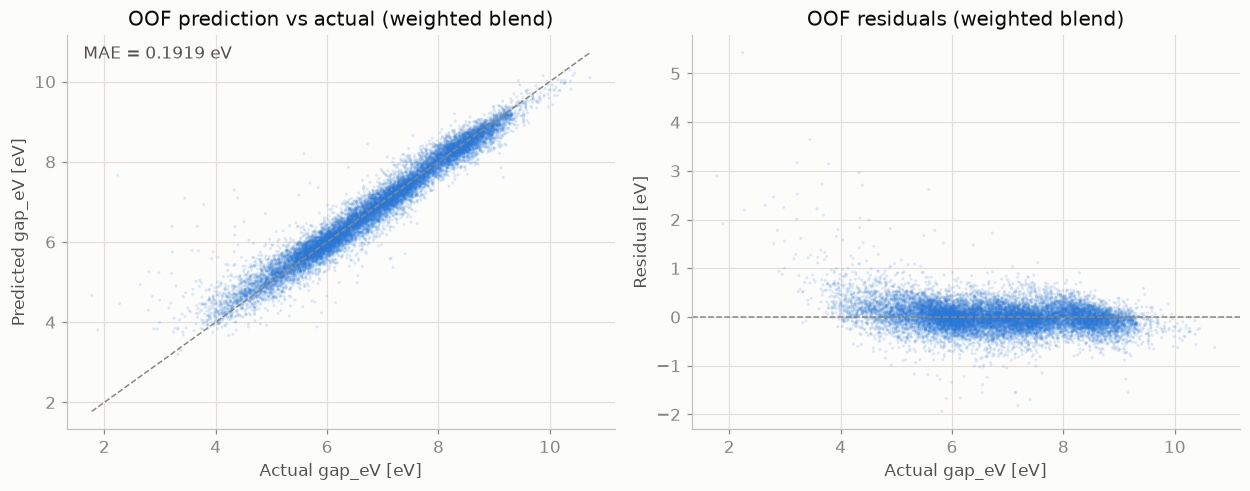

残差: mean = +0.0029, std = 0.2781, |residual| > 1 eV: 90 件


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
ax = axes[0]
ax.scatter(y, oof_blend, s=4, alpha=0.15, color=C_BLUE, edgecolors="none", rasterized=True)
lims = [min(y.min(), oof_blend.min()), max(y.max(), oof_blend.max())]
ax.plot(lims, lims, ls="--", lw=1.0, color=C_MUTED)
ax.set_title("OOF prediction vs actual (weighted blend)")
ax.set_xlabel("Actual gap_eV [eV]")
ax.set_ylabel("Predicted gap_eV [eV]")
ax.text(0.03, 0.94, f"MAE = {best_mae:.4f} eV", transform=ax.transAxes, color=C_SEC)

ax = axes[1]
res = oof_blend - y
ax.scatter(y, res, s=4, alpha=0.15, color=C_BLUE, edgecolors="none", rasterized=True)
ax.axhline(0.0, ls="--", lw=1.0, color=C_MUTED)
ax.set_title("OOF residuals (weighted blend)")
ax.set_xlabel("Actual gap_eV [eV]")
ax.set_ylabel("Residual [eV]")
plt.tight_layout()
plt.show()
print(f"残差: mean = {res.mean():+.4f}, std = {res.std():.4f}, "
      f"|residual| > 1 eV: {(np.abs(res) > 1).sum()} 件")

## 10. 学習データ全体で再学習してテストデータを予測

CV で決めたパラメータを使い，学習データ全体で各モデルを 1 回ずつ学習し直す．early stopping は使えないため，木の本数は CV の平均 best_iteration に，fold あたりの学習データが 4/5 だったことを補正する係数（5/4 倍）を掛けた値にする．予測値は学習データの `gap_eV` の範囲にクリップして極端な外挿を抑える．

In [14]:
def refit_n(iters):
    return int(np.mean(iters) * N_SPLITS / (N_SPLITS - 1)) + 50


lgb_final = lgb.LGBMRegressor(**{**lgb_params, "n_estimators": refit_n(lgb_iters)})
xgb_final = xgb.XGBRegressor(**{**xgb_params, "n_estimators": refit_n(xgb_iters),
                                "early_stopping_rounds": None})
cat_final = CatBoostRegressor(**{**CAT_PARAMS, "iterations": refit_n(cat_iters)})

t0 = time.time()
lgb_final.fit(X_train, y)
xgb_final.fit(X_train, y, verbose=False)
cat_final.fit(X_train, y)
print(f"再学習: {time.time() - t0:.0f} 秒 (trees: lgb {refit_n(lgb_iters)}, "
      f"xgb {refit_n(xgb_iters)}, cat {refit_n(cat_iters)})")

lo, hi = float(y.min()), float(y.max())
pred_lgb = np.clip(lgb_final.predict(X_test), lo, hi)
pred_xgb = np.clip(xgb_final.predict(X_test), lo, hi)
pred_cat = np.clip(cat_final.predict(X_test), lo, hi)
pred_stack = np.column_stack([pred_lgb, pred_xgb, pred_cat])
pred_blend = np.clip(pred_stack @ best_w, lo, hi)
pred_mean = np.clip(pred_stack.mean(axis=1), lo, hi)
pd.DataFrame({"LightGBM": pred_lgb, "XGBoost": pred_xgb, "CatBoost": pred_cat,
              "blend": pred_blend}).describe().round(3)

再学習: 4581 秒 (trees: lgb 4424, xgb 4221, cat 7547)


,LightGBM,XGBoost,CatBoost,blend
count,4000.000,4000.000,4000.000,4000.000
mean,6.881,6.868,6.870,6.869
std,1.169,1.183,1.183,1.181
min,3.764,3.642,3.509,3.580
25%,5.938,5.930,5.933,5.933
50%,6.834,6.819,6.828,6.821
75%,7.861,7.842,7.871,7.857
max,9.605,9.882,9.714,9.787


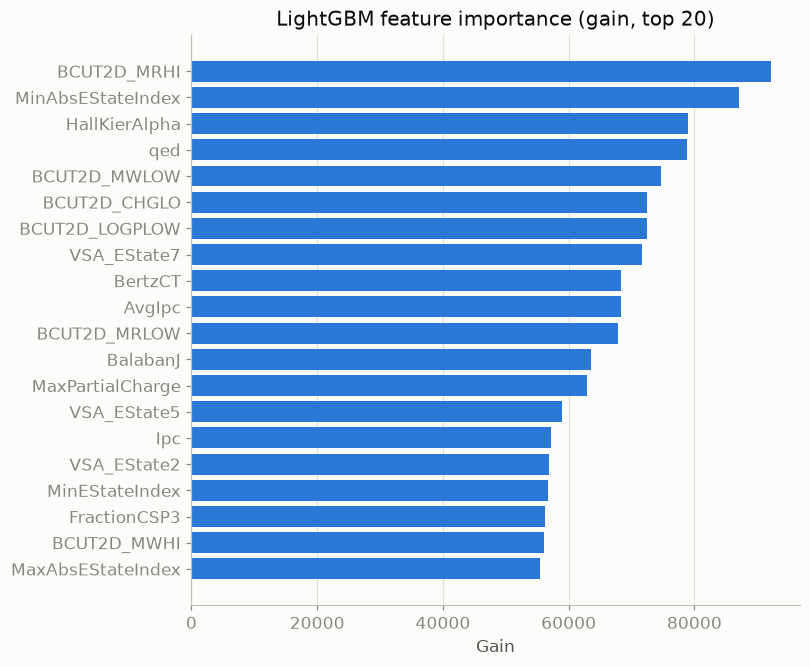

In [15]:
imp = pd.Series(lgb_final.booster_.feature_importance(importance_type="gain"),
                index=feat_names)
top = imp.sort_values(ascending=False).head(20)[::-1]
fig, ax = plt.subplots(figsize=(7.5, 6.2))
ax.barh(list(top.index), top.to_numpy(), color=C_BLUE)
ax.set_title("LightGBM feature importance (gain, top 20)")
ax.set_xlabel("Gain")
ax.grid(False, axis="y")
plt.tight_layout()
plt.show()

## 11. 提出ファイルの作成（最大 3 モデル枠）

| ファイル | 内容 |
| --- | --- |
| `submission.csv` | 本命：OOF で重み最適化した 3 モデルブレンド |
| `submission_2_lightgbm_single.csv` | チューニング済み LightGBM 単体 |
| `submission_3_mean_blend.csv` | 3 モデルの単純平均 |

複数提出時のファイル名は規則で未指定のため，本命のみ規定名 `submission.csv` とした．保存時に行数・列順・欠損・`smiles` の対応を assert で検証する．

In [16]:
def save_submission(pred, path):
    sub = pd.DataFrame({"smiles": test_df["smiles"].to_numpy(), "gap_eV": pred})
    assert list(sub.columns) == ["smiles", "gap_eV"]
    assert len(sub) == 4000, f"行数が {len(sub)} 行になっている"
    assert sub["gap_eV"].notna().all() and np.isfinite(sub["gap_eV"].to_numpy()).all()
    assert (sub["smiles"].to_numpy() == test_df["smiles"].to_numpy()).all()
    sub.to_csv(path, index=False)
    print(f"{path}: {len(sub)} 行を保存した")
    return sub


sub_blend = save_submission(pred_blend, "submission.csv")
sub_lgb = save_submission(pred_lgb, "submission_2_lightgbm_single.csv")
sub_mean = save_submission(pred_mean, "submission_3_mean_blend.csv")
sub_blend.head()

submission.csv: 4000 行を保存した
submission_2_lightgbm_single.csv: 4000 行を保存した
submission_3_mean_blend.csv: 4000 行を保存した


,smiles,gap_eV
0,CC1(CN1)C(C#C)C#N,7.260485
1,C1CC11C2OC2C11CO1,8.274349
2,OC1CC1C1CC(O)C1,8.641331
3,OC1C=CC2COC12,6.738814
4,CC1OC1CNC(N)=O,8.011203


## 12. 当日評価（正解付きテストデータの配布後に実行）

`qm9_bandgap_test_with_answer.csv` が同じフォルダまたは 1 つ上の階層にあれば，3 つの提出値の MAE を計算する．未配布の場合はスキップする．

In [17]:
answer_path = None
for cand in ["qm9_bandgap_test_with_answer.csv",
             os.path.join("..", "qm9_bandgap_test_with_answer.csv")]:
    if os.path.exists(cand):
        answer_path = cand
        break

preds_final = {
    "submission.csv (weighted blend)": pred_blend,
    "submission_2 (LightGBM single)": pred_lgb,
    "submission_3 (mean blend)": pred_mean,
}
if answer_path is None:
    print("qm9_bandgap_test_with_answer.csv が見つからないためスキップする（当日配布後に再実行）")
else:
    ans = pd.read_csv(answer_path)
    print(f"{answer_path} を読み込んだ: {ans.shape}, 列 = {list(ans.columns)}")
    if "gap_eV" not in ans.columns or "smiles" not in ans.columns:
        print("smiles / gap_eV 列が見つからない．列名を確認して再実行する")
    elif len(ans) == len(test_df) and (ans["smiles"].to_numpy()
                                       == test_df["smiles"].to_numpy()).all():
        for name, p in preds_final.items():
            print(f"test MAE = {mean_absolute_error(ans['gap_eV'], p):.4f} eV | {name}")
    else:
        print("行順が一致しないため smiles で結合して評価する")
        pred_df = pd.DataFrame({"smiles": test_df["smiles"].to_numpy(),
                                "pred_blend": pred_blend, "pred_lgb": pred_lgb,
                                "pred_mean": pred_mean})
        merged = ans.merge(pred_df, on="smiles", how="inner")
        print(f"結合後 {len(merged)} 行")
        for name, col in [("submission.csv (weighted blend)", "pred_blend"),
                          ("submission_2 (LightGBM single)", "pred_lgb"),
                          ("submission_3 (mean blend)", "pred_mean")]:
            print(f"test MAE = {mean_absolute_error(merged['gap_eV'], merged[col]):.4f} eV | {name}")

qm9_bandgap_test_with_answer.csv が見つからないためスキップする（当日配布後に再実行）


## 13. まとめ

OOF MAE の一覧と，採用したブレンド重み・総実行時間を表示する．

In [18]:
result = pd.DataFrame({
    "model": ["Baseline LightGBM", "LightGBM (tuned)", "XGBoost (tuned)", "CatBoost",
              "Mean blend", "Weighted blend (submission.csv)"],
    "OOF MAE [eV]": [mean_absolute_error(y, o) for o in
                     [oof_base, oof_lgb, oof_xgb, oof_cat, oof_mean, oof_blend]],
}).round(4)
display(result)
best_row = result.loc[result["OOF MAE [eV]"].idxmin()]
print(f"最良: {best_row['model']} (OOF MAE {best_row['OOF MAE [eV]']:.4f} eV)")
print(f"ブレンド重み: LightGBM {best_w[0]:.2f} / XGBoost {best_w[1]:.2f} / "
      f"CatBoost {best_w[2]:.2f}")
print(f"総実行時間: {(time.time() - T_START) / 60:.1f} 分")

,model,OOF MAE [eV]
0,Baseline LightGBM,0.2054
1,LightGBM (tuned),0.2054
2,XGBoost (tuned),0.1967
3,CatBoost,0.1963
4,Mean blend,0.1931
5,Weighted blend (submission.csv),0.1919


最良: Weighted blend (submission.csv) (OOF MAE 0.1919 eV)
ブレンド重み: LightGBM 0.04 / XGBoost 0.46 / CatBoost 0.50
総実行時間: 328.5 分


## 14. 口頭説明（1 分間）の下書きと提出前チェック

### 口頭説明の下書き

> SMILES から RDKit で 3 種類の特徴量（2D 記述子 217 個，Morgan カウントフィンガープリント 2048 次元，MACCS keys 167 次元）を作り，LightGBM・XGBoost・CatBoost の 3 つの勾配ブースティングモデルを学習しました．LightGBM と XGBoost は Optuna で交差検証 MAE を目的関数にしてハイパーパラメータを探索し，5-fold の Out-of-Fold 予測だけを使って 3 モデルの重み付き平均の重みを決めました．テストデータの情報を一切使わないリークのない検証で，ブレンドが単体モデルより MAE を改善することを確認しています．乱数シードは推奨値の 8 です．

### 提出前チェックリスト（規則 7 章）

| 項目 | 状態 |
| --- | --- |
| 配布データ以外を追加していない | ✓（特徴量はすべて `smiles` から生成） |
| SMILES から特徴量を生成している | ✓（記述子・Morgan・MACCS） |
| モデルを 0 から学習させている | ✓（本ノートブック内で学習） |
| LLM・NNP を組み込んでいない | ✓（勾配ブースティング決定木のみ） |
| 最終値にモデルの予測値を使用 | ✓ |
| 提出モデルが 3 個以内 | ✓（基礎モデル 3 個．組み合わせは規則 5.2 で許可） |
| `submission.csv` の列が `smiles,gap_eV` の順 | ✓（保存時に assert で確認） |
| 4,000 件の smiles と予測値が 1 対 1 | ✓（保存時に assert で確認） |
| MAE で性能を確認している | ✓（OOF MAE を「13. まとめ」に記載） |
| 5 用語を解説できる | ✓（冒頭の用語解説を参照） |
| 工夫した点を 1 分で説明できる | ✓（上記の下書き） |
| 乱数シードの記録 | ✓（`SEED = 8`） |

### 主催者への確認事項

- ブレンド（複数モデルの予測値の組み合わせ）を提出する場合のモデル数の数え方．
- 複数の提出 CSV を出す場合のファイル名（本ノートブックでは本命のみ規定名 `submission.csv` とした）．